# Raw Data for "Optimizing quantum gates towards the scale of logical qubits"

***Nature Communications 15, 2442 (2024)***
- [Main Text](https://www.nature.com/articles/s41467-024-46623-y)
- [Supplementary Information](https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-024-46623-y/MediaObjects/41467_2024_46623_MOESM1_ESM.pdf)

**Authors**

*Paul V. Klimov, Andreas Bengtsson, Chris Quintana, Alexandre Bourassa, Sabrina Hong, Andrew Dunsworth, Kevin J. Satzinger, William P. Livingston, Volodymyr Sivak, Murphy Yuezhen Niu, Trond I. Andersen, Yaxing Zhang, Desmond Chik, Zijun Chen, Charles Neill, Catherine Erickson, Alejandro Grajales Dau, Anthony Megrant, Pedram Roushan, Alexander N. Korotkov, Julian Kelly, Vadim Smelyanskiy, Yu Chen & Hartmut Neven*

**File Structure**
- `nat_comm_15_2442_2024.ipynb` - This notebook.
- `figure_2a_processed.csv` - Data for Figure 2a.
- `figure_2b_processed.csv` - Data for Figure 2b.
- `figure_2c_processed.csv` - Data for Figure 2c.
- `figure_3a_processed.csv` - Data for Figure 3a.
- `figure_4a_processed.csv` - Data for Figure 4a.
- `figure_4b_processed.csv` - Data for Figure 4b.
- `figure_4c_processed.csv` - Data for Figure 4c.
- `figure_4d_processed.csv` - Data for Figure 4d.

**Notebook Structure**

- `Imports` - Python imports necessary to execute all cells of the notebook.
- `Helpers` - Functions necessary to execute all cells of the notebook.
- `File Directory` - User specified directory where data files are stored.
- `Figure X` - Loads data corresponding to Figure X in the main text.
  - We only produce plots that can be made via trivial `matplotlib` code.

**Data Structure**

Data are packaged into `.csv` files and loaded into `pandas` `Dataframe`s for inspection, each of which has a similar structure. All terminology was chosen to match the publication, which should be referenced for context. Nonetheless, we provide definitions for common terms below.

Rows correspond to distinct configurations of our 68 qubit quantum processor.

- `Baseline` - Random baseline configuration, used as a standard.
- `Crossover` - Crossover configuration, used as a standard.
- `Optimized` - Optimized configuration.
- `Healed` - Healed configuration.
- `Region X` - One of multiple regions that are merged during stitching.
- `Merged Regions` - Multiple regions after merging and stitching.
- `Healed Regions` - Multiple regions after merging, stitching, and healing.

Columns correspond to relevant characteristics of each configuration.

- `N` - The number of qubits in the relevant configuration.
  - `NaN` entries correspond to baseline configurations that were not optimized.
  - `Smax` entries corrrespond to global optimization of all frequencies simultanously.
- `Scope` - The scope with which the relevant configuration was optimized.
- `CZXEB` - Two qubit cycle error benchmarks for interacting qubit pairs in the relevant configuration.
  - `None` entries correspond to interacting qubit pairs which encountered calibration failures and were not benchmarked.
- `SQRB` - Single qubit randomized benchmarks for qubits in the relevant configuration.
  - `None` entries correspond to qubits which encountered calibration failures and were not benchmarked.
- `idle_freqs_GHz` - Idle frequencies in GHz for qubits in the relevant configuration.
- `int_freqs_GHz` - Interaction frequencies in GHz for interacting qubit pairs in the relevant confiugration.
- `Calibration Failures` - Total number of qubits and pairs which encountered calibration failures and could not be benchmarked.

Qubits and pairs are defined as follows.
- Qubit with coordinates `(row A, col B)` is defined as the `str` `'qA_B'`.
- Pair of interacting qubits with coordinates `(row A, col B)` and `(row C, col D)` is defined as the `tuple[str, str]` `('qA_B', 'qC_D')`.

The processor connectivity is as follows.

```
                                              (0, 5)
                                              │
                                              │
                                    (1, 4)────(1, 5)
                                    │         │
                                    │         │
                           (2, 3)───(2, 4)────(2, 5)────(2, 6)────(2, 7)
                           │        │         │         │         │
                           │        │         │         │         │
                  (3, 2)───(3, 3)───(3, 4)────(3, 5)────(3, 6)────(3, 7)───(3, 8)
                  │        │        │                   │         │
                  │        │        │                   │         │
         (4, 1)───(4, 2)───(4, 3)───(4, 4)              (4, 6)────(4, 7)            (4, 9)
         │        │        │        │                   │         │                 │
         │        │        │        │                   │         │                 │
(5, 0)───(5, 1)───(5, 2)───(5, 3)───(5, 4)────(5, 5)────(5, 6)────(5, 7)───(5, 8)───(5, 9)───(5, 10)
│        │        │        │        │         │         │         │        │        │        │
│        │        │        │        │         │         │         │        │        │        │
(6, 0)───(6, 1)───(6, 2)───(6, 3)───(6, 4)────(6, 5)────(6, 6)────(6, 7)───(6, 8)───(6, 9)───(6, 10)
         │        │        │        │         │         │         │        │        │
         │        │        │        │         │         │         │        │        │
         (7, 1)───(7, 2)───(7, 3)───(7, 4)────(7, 5)────(7, 6)────(7, 7)───(7, 8)───(7, 9)
                  │        │        │         │         │         │        │
                  │        │        │         │         │         │        │
                  (8, 2)───(8, 3)───(8, 4)────(8, 5)────(8, 6)────(8, 7)───(8, 8)
                                    │         │         │         │
                                    │         │         │         │
                                    (9, 4)────(9, 5)────(9, 6)────(9, 7)
                                    │         │         │
                                    │         │         │
                                    (10, 4)───(10, 5)───(10, 6)
                                              │
                                              │
                                              (11, 5)
```

# Imports

In [ ]:
import os

from ast import literal_eval
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Helpers

In [ ]:
def parse_data_string(data_string: str) -> dict[str, float] | dict[tuple[str, str], float]:
    """Parses qubit or qubit pair data stored in DataFrames.

    Args:
        data_string: Data supplied as a string with format
            '((device, data), ...)'
                device:
                    qubit: str
                    pair: tuple[str, str]
                data: error or frequency data.

    Returns:
        Data dictionary with format {device: data}.
    """
    return {device: data for device, data in literal_eval(data_string) if data}


def build_box_plot_kwargs(widths: float = 0.3, color: str = "C0") -> dict[str, Any]:
    """Constructs keyword arguments for matplotlib.pyplot.boxplot.

    Args:
        widths: Width of each box in the box plot.
        color: Color of each box in the box plot.

    Returns:
        Keyword arguments for matplotlib.pyplot.boxplot.
    """
    return {
        "meanline": False,
        "showmeans": True,
        "widths": widths,
        "showfliers": False,
        "autorange": True,
        "whis": (2.5, 97.5),
        "meanprops": dict(marker="D", markeredgecolor="white", markerfacecolor=color, ms=5, lw=3),
        "medianprops": dict(
            marker=None,
            color="white",
            markeredgecolor="white",
            markerfacecolor="white",
            ms=5,
            lw=1.5,
        ),
        "flierprops": dict(marker=".", color=color, markeredgecolor=color),
        "boxprops": dict(color=color, facecolor=color),
        "whiskerprops": dict(color=color),
        "capprops": dict(color=color),
        "patch_artist": True,
    }

# File Directory

In [ ]:
DIRECTORY: str = "Enter the directory where EXPECTED_FILES below are stored."
DIRECTORY

In [ ]:
EXPECTED_FILES: list[str] = [
    "figure_2a_processed.csv",
    "figure_2b_processed.csv",
    "figure_2c_processed.csv",
    "figure_3a_processed.csv",
    "figure_4a_processed.csv",
    "figure_4b_processed.csv",
    "figure_4c_processed.csv",
    "figure_4d_processed.csv",
]
EXPECTED_FILES

In [ ]:
DISCOVERED_FILES = os.listdir(DIRECTORY)
DISCOVERED_FILES

In [ ]:
MISSING_FILES = set(EXPECTED_FILES) - set(DISCOVERED_FILES)

if MISSING_FILES:
    raise ValueError(f"\n{MISSING_FILES=}. \nEnsure\n{DIRECTORY=} \ncontains \n{EXPECTED_FILES=}.")

# Figure 2

In [ ]:
figure_2a_df = pd.read_csv(DIRECTORY + "figure_2a_processed.csv", index_col=0)
figure_2a_df

,Qubits,Scope,Healed,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Baseline,68,NaN,False,"((('q6_5', 'q6_6'), 0.01485099501993356), (('q...","(('q0_5', 0.000941515431095663), ('q1_4', 0.00...","(('q0_5', 5.7999999999995815), ('q1_4', 5.8559...","((('q6_5', 'q6_6'), 6.079999999999551), (('q7_...",1
Crossover,49,NaN,False,"((('q3_7', 'q4_7'), 0.006591005751393292), (('...","(('q1_4', 0.000689838792190256), ('q1_5', 0.00...",(),(),0


In [ ]:
figure_2b_df = pd.read_csv(DIRECTORY + "figure_2b_processed.csv", index_col=0)
figure_2b_df

,Qubits,Scope,Healed,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Optimized,68,1,False,"((('q6_9', 'q7_9'), 0.02352164926385053), (('q...","(('q0_5', 0.0005302315839809113), ('q1_4', 0.0...","(('q0_5', 6.0999999999995485), ('q1_4', 5.9219...","((('q6_9', 'q7_9'), 6.075999999999551), (('q7_...",5
Optimized,68,2,False,"((('q6_9', 'q7_9'), 0.013205721283264027), (('...","(('q0_5', 0.0006595060204841463), ('q1_4', 0.0...","(('q0_5', 6.133999999999545), ('q1_4', 5.92199...","((('q6_9', 'q7_9'), 6.073737367548496), (('q7_...",0
Optimized,68,3,False,"((('q6_9', 'q7_9'), 0.013330914828195345), (('...","(('q0_5', 0.0010540899221389566), ('q1_4', 0.0...","(('q0_5', 5.8359999999995775), ('q1_4', 5.9809...","((('q6_9', 'q7_9'), 6.08638424115544), (('q7_6...",0
Optimized,68,4,False,"((('q6_9', 'q7_9'), 0.010039648714005617), (('...","(('q0_5', 0.0009884024267307057), ('q1_4', 0.0...","(('q0_5', 6.142339693910159), ('q1_4', 5.93110...","((('q6_9', 'q7_9'), 6.073966849969585), (('q7_...",0
Optimized,68,5,False,"((('q6_9', 'q7_9'), 0.003916654839899614), (('...","(('q0_5', 0.0004487448766956059), ('q1_4', 0.0...","(('q0_5', 6.132139252634868), ('q1_4', 5.91110...","((('q6_9', 'q7_9'), 6.065445320228703), (('q7_...",0
Optimized,68,6,False,"((('q6_9', 'q7_9'), 0.04512550023501011), (('q...","(('q0_5', 0.0006344412469599381), ('q1_4', 0.0...","(('q0_5', 5.862136457047851), ('q1_4', 5.78646...","((('q6_9', 'q7_9'), 6.064238708232983), (('q7_...",2
Optimized,68,Smax,False,"((('q6_9', 'q7_9'), 0.00932553606106884), (('q...","(('q0_5', 0.001419162104098648), ('q1_4', 0.00...","(('q0_5', 5.590699939954849), ('q1_4', 5.64444...","((('q6_9', 'q7_9'), 6.090242063890088), (('q7_...",1


In [ ]:
figure_2c_df = pd.read_csv(DIRECTORY + "figure_2c_processed.csv", index_col=0)
figure_2c_df

,Qubits,Scope,Healed,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Healed,68,1,True,"((('q6_9', 'q7_9'), 0.014316341399119886), (('...","(('q0_5', 0.0007350471455517815), ('q1_4', 0.0...","(('q0_5', 6.0999999999995485), ('q1_4', 5.9219...","((('q6_9', 'q7_9'), 6.08199999999955), (('q7_6...",3
Healed,68,2,True,"((('q6_9', 'q7_9'), 0.011480779136791686), (('...","(('q0_5', 0.0006940657453310961), ('q1_4', 0.0...","(('q0_5', 6.133999999999545), ('q1_4', 5.92199...","((('q6_9', 'q7_9'), 6.063954814201765), (('q7_...",0
Healed,68,3,True,"((('q6_9', 'q7_9'), 0.025540013240154674), (('...","(('q0_5', 0.001039274025388337), ('q1_4', 0.00...","(('q0_5', 5.8359999999995775), ('q1_4', 5.9809...","((('q6_9', 'q7_9'), 6.095226514864947), (('q7_...",0
Healed,68,4,True,"((('q6_9', 'q7_9'), 0.009986722419961791), (('...","(('q0_5', 0.0006869925271552058), ('q1_4', 0.0...","(('q0_5', 6.142339693910159), ('q1_4', 5.93110...","((('q6_9', 'q7_9'), 6.073966849969585), (('q7_...",1
Healed,68,5,True,"((('q6_9', 'q7_9'), 0.013590594098513736), (('...","(('q0_5', 0.00048603258654639214), ('q1_4', 0....","(('q0_5', 6.132139252634868), ('q1_4', 5.91110...","((('q6_9', 'q7_9'), 6.065445320228703), (('q7_...",0
Healed,68,6,True,"((('q6_9', 'q7_9'), 0.011594938188463633), (('...","(('q0_5', 0.0008172879025433177), ('q1_4', 0.0...","(('q0_5', 5.862136457047851), ('q1_4', 5.78646...","((('q6_9', 'q7_9'), 6.072666252574994), (('q7_...",0
Healed,68,Smax,True,"((('q6_9', 'q7_9'), 0.013130080039517517), (('...","(('q0_5', 0.0016556108593216434), ('q1_4', 0.0...","(('q0_5', 5.590699939954849), ('q1_4', 5.97399...","((('q6_9', 'q7_9'), 6.090242063890088), (('q7_...",0


Text(0.5, 0, 'Scope (S)')

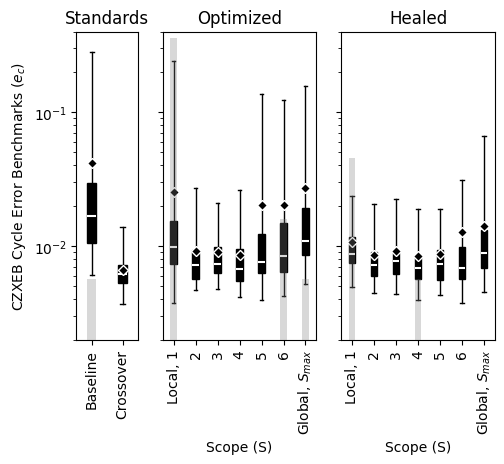

In [ ]:
# Define Plot
fig, axes = plt.subplots(
    1, 3, figsize=(12, 4), sharey=True, gridspec_kw={"width_ratios": [0.2, 0.5, 0.5]}
)
fig.set_size_inches(0.45 * 12, 4)
plt.subplots_adjust(wspace=0.2, hspace=0.1)
right_axes = [ax.twinx() for ax in axes]

# Plot Standards
for pos, (index, row) in enumerate(figure_2a_df.iterrows()):
    czxeb = parse_data_string(row["CZXEB"])
    axes[0].boxplot(czxeb.values(), positions=[pos], **build_box_plot_kwargs(color="k"))
    right_axes[0].bar([pos], row["Calibration Failures"], color="grey", width=0.3, alpha=0.3)

# Plot Optimized
for pos, (index, row) in enumerate(figure_2b_df.iterrows()):
    czxeb = parse_data_string(row["CZXEB"])
    axes[1].boxplot(czxeb.values(), positions=[pos], **build_box_plot_kwargs(color="k"))
    right_axes[1].bar([pos], row["Calibration Failures"], color="grey", width=0.3, alpha=0.3)

# Plot Healed
for pos, (index, row) in enumerate(figure_2c_df.iterrows()):
    czxeb = parse_data_string(row["CZXEB"])
    axes[2].boxplot(czxeb.values(), positions=[pos], **build_box_plot_kwargs(color="k"))
    right_axes[2].bar([pos], row["Calibration Failures"], color="grey", width=0.3, alpha=0.3)

# Format Axes
for axis in axes:
    axis.set_ylim(2e-3, 4e-1)
    axis.set_yscale("log")
    axis.set_frame_on(False)

for right_axis in right_axes:
    right_axis.set_xticks([])
    right_axis.set_yticks([])
    right_axis.set_ylim(0, 5.1)

axes[0].set_ylabel(r"CZXEB Cycle Error Benchmarks ($e_c$)")
axes[0].set_title("Standards")
axes[0].set_xticks((0, 1))
axes[0].set_xticklabels(("Baseline", "Crossover"), rotation=90)

axes[1].set_title("Optimized")
axes[1].set_xticks((0, 1, 2, 3, 4, 5, 6))
axes[1].set_xticklabels(("Local, 1", "2", "3", "4", "5", "6", r"Global, $S_{max}$"), rotation=90)
axes[1].set_xlabel("Scope (S)")

axes[2].set_title("Healed")
axes[2].set_xticks((0, 1, 2, 3, 4, 5, 6))
axes[2].set_xticklabels(("Local, 1", "2", "3", "4", "5", "6", r"Global, $S_{max}$"), rotation=90)
axes[2].set_xlabel("Scope (S)")

# Figure 3

In [ ]:
figure_3a_df = pd.read_csv(DIRECTORY + "figure_3a_processed.csv", index_col=0)
figure_3a_df

,N,Scope,Dephasing,Relaxation,Stray Coupling,Pulse Distortion,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Baseline,68,NaN,False,False,False,False,"((('q7_6', 'q8_6'), 0.04331119418081311), (('q...","(('q0_5', 0.000941515431095663), ('q1_4', 0.00...","(('q0_5', 5.7999999999995815), ('q1_4', 5.8559...","((('q7_6', 'q8_6'), 6.021999999999557), (('q8_...",1
Optimized,68,2.0,True,False,False,False,"((('q9_5', 'q10_5'), 0.22216660286376808), (('...","(('q0_5', 0.03218520638164302), ('q1_4', 0.005...","(('q0_5', 6.139999999999544), ('q1_4', 5.98399...","((('q9_5', 'q10_5'), 5.8854875473358685), (('q...",10
Optimized,68,2.0,False,True,False,False,"((('q9_5', 'q10_5'), 0.00833768686075645), (('...","(('q0_5', 0.0008548197225463072), ('q1_4', 0.0...","(('q0_5', 5.99399999999956), ('q1_4', 5.983999...","((('q9_5', 'q10_5'), 5.82509818714766), (('q6_...",0
Optimized,68,2.0,False,False,True,False,"((('q9_5', 'q10_5'), 0.018766316345928707), ((...","(('q0_5', 0.000883745531940705), ('q1_4', 0.00...","(('q0_5', 6.137999999999544), ('q1_4', 5.64443...","((('q9_5', 'q10_5'), 5.807405541499756), (('q6...",5
Optimized,68,2.0,False,False,False,True,"((('q9_5', 'q10_5'), 0.029407920635757617), ((...","(('q0_5', 0.0051228553615605965), ('q1_4', 0.0...","(('q0_5', 5.873999999999573), ('q1_4', 5.87053...","((('q9_5', 'q10_5'), 5.733904261741437), (('q6...",19
Optimized,68,2.0,True,True,False,False,"((('q9_5', 'q10_5'), 0.07300749739262302), (('...","(('q0_5', 0.0009302759282011075), ('q1_4', 0.0...","(('q0_5', 6.139999999999544), ('q1_4', 5.96999...","((('q9_5', 'q10_5'), 5.880655724383964), (('q6...",3
Optimized,68,2.0,True,False,True,False,"((('q9_5', 'q10_5'), 0.012849127845689645), ((...","(('q0_5', 0.0007174661257805526), ('q1_4', 0.0...","(('q0_5', 6.095999999999549), ('q1_4', 5.91256...","((('q9_5', 'q10_5'), 5.882328830961786), (('q6...",3
Optimized,68,2.0,True,False,False,True,"((('q9_5', 'q10_5'), 0.009401952139030723), ((...","(('q0_5', 0.005296771689897062), ('q1_4', 0.00...","(('q0_5', 5.887999999999572), ('q1_4', 5.88292...","((('q9_5', 'q10_5'), 5.882089019239857), (('q6...",4
Optimized,68,2.0,False,True,True,False,"((('q9_5', 'q10_5'), 0.007812241753525184), ((...","(('q0_5', 0.00045182274307159487), ('q1_4', 0....","(('q0_5', 6.067999999999552), ('q1_4', 5.95999...","((('q9_5', 'q10_5'), 5.886551468961594), (('q6...",0
Optimized,68,2.0,False,True,False,True,"((('q9_5', 'q10_5'), 0.007219952082040154), ((...","(('q0_5', 0.0011049723516650678), ('q1_4', 0.0...","(('q0_5', 6.103999999999548), ('q1_4', 5.59710...","((('q9_5', 'q10_5'), 5.654762300013781), (('q6...",0


Text(0.5, 1.0, 'Activate Mitigation Strategies')

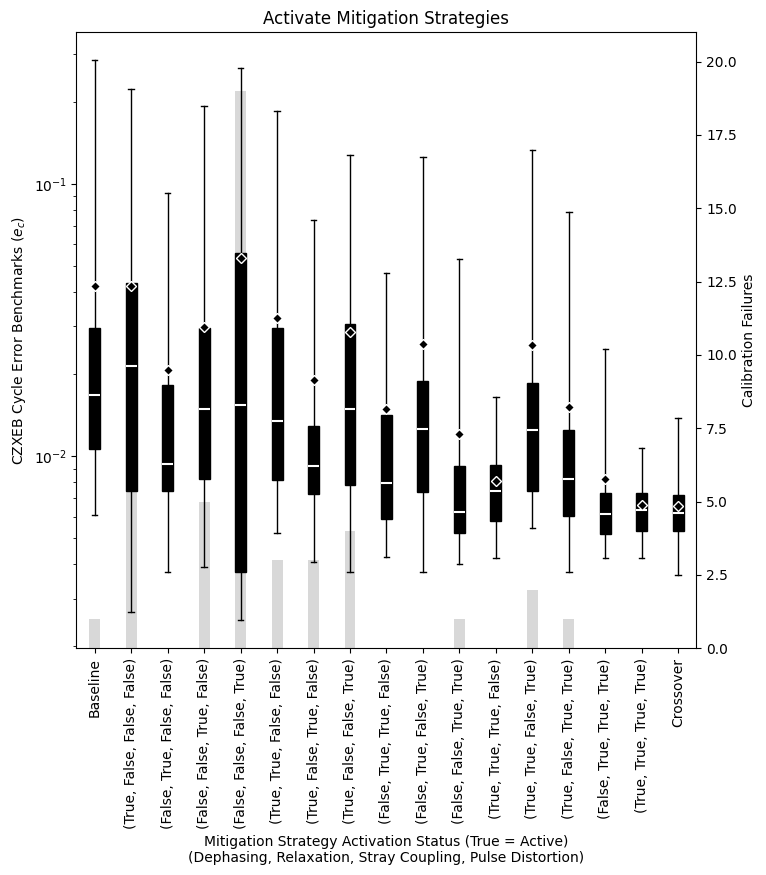

In [ ]:
# Define Plot
fig, axis = plt.subplots(1, figsize=(8, 8))
plt.subplots_adjust(wspace=0.2, hspace=0.1)
right_axis = axis.twinx()

# Plot Configurations
xticklabels: list[str | tuple[str, str, str, str]] = []
for pos, (index, row) in enumerate(figure_3a_df.iterrows()):
    czxeb = parse_data_string(row["CZXEB"])
    axis.boxplot(czxeb.values(), positions=[pos], **build_box_plot_kwargs(color="k"))
    right_axis.bar([pos], row["Calibration Failures"], color="grey", width=0.3, alpha=0.3)
    xticklabels.append(
        (row["Dephasing"], row["Relaxation"], row["Stray Coupling"], row["Pulse Distortion"])
    )

xticklabels[0] = "Baseline"
xticklabels[-1] = "Crossover"
axis.set_xticks(range(len(figure_3a_df)))
axis.set_xticklabels(xticklabels, rotation=90)

# Format Axes
axis.set_yscale("log")
axis.set_frame_on(False)

right_axis.set_ylim(0, 21)
right_axis.set_zorder(-5)
right_axis.set_ylabel("Calibration Failures")

axis.set_ylabel(r"CZXEB Cycle Error Benchmarks ($e_c$)")
axis.set_xlabel(
    "Mitigation Strategy Activation Status (True = Active)"
    "\n(Dephasing, Relaxation, Stray Coupling, Pulse Distortion)"
)
axis.set_title("Activate Mitigation Strategies")

# Figure 4a

In [ ]:
figure_4a_df = pd.read_csv(DIRECTORY + "figure_4a_processed.csv", index_col=0)
figure_4a_df

,N,Scope,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Baseline,2,NaN,"((('q4_3', 'q5_3'), 0.004070337194181428), (('...","(('q2_5', 0.0006100093584572308), ('q3_5', 0.0...","(('q2_5', 5.757999999999586), ('q3_5', 6.12799...","((('q4_3', 'q5_3'), 5.611999999999602), (('q6_...",1
Baseline,2,NaN,"((('q2_3', 'q2_4'), 0.010224931898022982), (('...","(('q2_3', 0.0018905901369126732), ('q2_4', 0.0...","(('q2_3', 6.121999999999546), ('q2_4', 6.13799...","((('q2_3', 'q2_4'), 5.767999999999585), (('q4_...",0
Baseline,2,NaN,"((('q6_8', 'q7_8'), 0.01684402678041194), (('q...","(('q2_4', 0.000559722207492952), ('q3_4', 0.00...","(('q2_4', 5.80999999999958), ('q3_4', 5.689999...","((('q6_8', 'q7_8'), 5.9999999999995595), (('q6...",0
Baseline,2,NaN,"((('q4_2', 'q4_3'), 0.005099561794246671), (('...","(('q2_4', 0.0008016623983607696), ('q2_5', 0.0...","(('q2_4', 6.009999999999558), ('q2_5', 5.71399...","((('q4_2', 'q4_3'), 5.845999999999576), (('q6_...",0
Baseline,2,NaN,"((('q5_3', 'q6_3'), 0.004258067857940084), (('...","(('q5_3', 0.0006063972996275258), ('q5_7', 0.0...","(('q5_3', 5.965999999999563), ('q5_7', 5.99399...","((('q5_3', 'q6_3'), 5.99799999999956), (('q7_5...",0
...,...,...,...,...,...,...,...
Optimized,47,2.0,"((('q9_6', 'q10_6'), 0.006014776039316022), ((...","(('q1_4', 0.0005004022652055906), ('q1_5', 0.0...","(('q1_4', 5.824496469031739), ('q1_5', 6.03799...","((('q9_6', 'q10_6'), 5.893999999999571), (('q3...",0
Optimized,54,2.0,"((('q8_7', 'q9_7'), 0.006807916625269084), (('...","(('q3_2', 0.0006403242782767049), ('q3_3', 0.0...","(('q3_2', 5.955309015194794), ('q3_3', 5.93199...","((('q8_7', 'q9_7'), 5.803666574823029), (('q3_...",0
Optimized,62,2.0,"((('q8_7', 'q9_7'), 0.007105820007012542), (('...","(('q1_4', 0.000657493588236191), ('q1_5', 0.00...","(('q1_4', 5.749999999999587), ('q1_5', 6.00409...","((('q8_7', 'q9_7'), 5.9076409511602845), (('q3...",0
Optimized,68,2.0,"((('q2_3', 'q3_3'), 0.0039652670011969815), ((...","(('q0_5', 0.0007708471063068711), ('q1_4', 0.0...","(('q0_5', 6.011999999999558), ('q1_4', 5.88363...","((('q2_3', 'q3_3'), 5.823559275000406), (('q6_...",0


In [ ]:
figure_4a_baselines_df = figure_4a_df.loc[figure_4a_df.index.str.contains("Baseline")]
figure_4a_baselines_df

,N,Scope,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Baseline,2,NaN,"((('q4_3', 'q5_3'), 0.004070337194181428), (('...","(('q2_5', 0.0006100093584572308), ('q3_5', 0.0...","(('q2_5', 5.757999999999586), ('q3_5', 6.12799...","((('q4_3', 'q5_3'), 5.611999999999602), (('q6_...",1
Baseline,2,NaN,"((('q2_3', 'q2_4'), 0.010224931898022982), (('...","(('q2_3', 0.0018905901369126732), ('q2_4', 0.0...","(('q2_3', 6.121999999999546), ('q2_4', 6.13799...","((('q2_3', 'q2_4'), 5.767999999999585), (('q4_...",0
Baseline,2,NaN,"((('q6_8', 'q7_8'), 0.01684402678041194), (('q...","(('q2_4', 0.000559722207492952), ('q3_4', 0.00...","(('q2_4', 5.80999999999958), ('q3_4', 5.689999...","((('q6_8', 'q7_8'), 5.9999999999995595), (('q6...",0
Baseline,2,NaN,"((('q4_2', 'q4_3'), 0.005099561794246671), (('...","(('q2_4', 0.0008016623983607696), ('q2_5', 0.0...","(('q2_4', 6.009999999999558), ('q2_5', 5.71399...","((('q4_2', 'q4_3'), 5.845999999999576), (('q6_...",0
Baseline,2,NaN,"((('q5_3', 'q6_3'), 0.004258067857940084), (('...","(('q5_3', 0.0006063972996275258), ('q5_7', 0.0...","(('q5_3', 5.965999999999563), ('q5_7', 5.99399...","((('q5_3', 'q6_3'), 5.99799999999956), (('q7_5...",0
...,...,...,...,...,...,...,...
Baseline,44,NaN,"((('q9_5', 'q9_6'), 0.02029532587690369), (('q...","(('q5_1', 0.0007761580846890603), ('q5_2', 0.0...","(('q5_1', 5.819999999999579), ('q5_2', 5.88999...","((('q9_5', 'q9_6'), 5.7819999999995835), (('q7...",0
Baseline,47,NaN,"((('q9_5', 'q9_6'), 0.01903581379031044), (('q...","(('q1_4', 0.0006628991239844284), ('q1_5', 0.0...","(('q1_4', 5.921999999999568), ('q1_5', 5.77399...","((('q9_5', 'q9_6'), 5.771999999999585), (('q3_...",4
Baseline,54,NaN,"((('q5_10', 'q6_10'), 0.007562734803518628), (...","(('q3_2', 0.0006373296135347428), ('q3_3', 0.0...","(('q3_2', 5.8359999999995775), ('q3_3', 5.6479...","((('q5_10', 'q6_10'), 5.883999999999572), (('q...",0
Baseline,62,NaN,"((('q6_8', 'q7_8'), 0.0479060682208268), (('q9...","(('q1_4', 0.0013370446041032769), ('q1_5', 0.0...","(('q1_4', 5.603999999999603), ('q1_5', 5.68599...","((('q6_8', 'q7_8'), 6.055999999999553), (('q9_...",9


In [ ]:
figure_4a_optimized_df = figure_4a_df.loc[figure_4a_df.index.str.contains("Optimized")]
figure_4a_optimized_df

,N,Scope,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Optimized,2,2.0,"((('q6_5', 'q6_6'), 0.003936944008293725), (('...","(('q2_5', 0.0006578025443085833), ('q2_6', 0.0...","(('q2_5', 6.027999999999556), ('q2_6', 6.26599...","((('q6_5', 'q6_6'), 6.137999999999544), (('q4_...",0
Optimized,2,2.0,"((('q4_6', 'q4_7'), 0.005397725834730888), (('...","(('q2_4', 0.0007229800022611754), ('q2_5', 0.0...","(('q2_4', 5.855999999999575), ('q2_5', 6.16999...","((('q4_6', 'q4_7'), 6.08599999999955), (('q8_2...",0
Optimized,2,2.0,"((('q3_6', 'q3_7'), 0.005567633038212366), (('...","(('q1_4', 0.0009646397824719655), ('q1_5', 0.0...","(('q1_4', 5.9719999999995625), ('q1_5', 6.1459...","((('q3_6', 'q3_7'), 6.105999999999548), (('q7_...",0
Optimized,2,2.0,"((('q3_5', 'q3_6'), 0.004697600207581282), (('...","(('q3_5', 0.0006876366262604794), ('q3_6', 0.0...","(('q3_5', 6.131999999999545), ('q3_6', 5.89599...","((('q3_5', 'q3_6'), 5.957999999999564), (('q7_...",0
Optimized,2,2.0,"((('q7_7', 'q7_8'), 0.0041977917267350395), ((...","(('q3_3', 0.0005170615543582113), ('q3_4', 0.0...","(('q3_3', 5.965999999999563), ('q3_4', 6.13399...","((('q7_7', 'q7_8'), 6.159999999999542), (('q5_...",0
...,...,...,...,...,...,...,...
Optimized,40,2.0,"((('q9_6', 'q10_6'), 0.006734732224477152), ((...","(('q5_2', 0.0005483530948577897), ('q5_3', 0.0...","(('q5_2', 5.881976660753537), ('q5_3', 5.99999...","((('q9_6', 'q10_6'), 6.013481208292502), (('q5...",0
Optimized,47,2.0,"((('q9_6', 'q10_6'), 0.006014776039316022), ((...","(('q1_4', 0.0005004022652055906), ('q1_5', 0.0...","(('q1_4', 5.824496469031739), ('q1_5', 6.03799...","((('q9_6', 'q10_6'), 5.893999999999571), (('q3...",0
Optimized,54,2.0,"((('q8_7', 'q9_7'), 0.006807916625269084), (('...","(('q3_2', 0.0006403242782767049), ('q3_3', 0.0...","(('q3_2', 5.955309015194794), ('q3_3', 5.93199...","((('q8_7', 'q9_7'), 5.803666574823029), (('q3_...",0
Optimized,62,2.0,"((('q8_7', 'q9_7'), 0.007105820007012542), (('...","(('q1_4', 0.000657493588236191), ('q1_5', 0.00...","(('q1_4', 5.749999999999587), ('q1_5', 6.00409...","((('q8_7', 'q9_7'), 5.9076409511602845), (('q3...",0


In [ ]:
figure_4a_stitched_df = figure_4a_df.loc[figure_4a_df.index.str.contains("Stitched")]
figure_4a_stitched_df

,N,Scope,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Stitched,68,2.0,"((('q8_7', 'q9_7'), 0.007367866529144507), (('...","(('q0_5', 0.0006422877290824247), ('q1_4', 0.0...","(('q0_5', 6.0899999999995496), ('q1_4', 5.9639...","((('q8_7', 'q9_7'), 5.804712412392228), (('q3_...",0


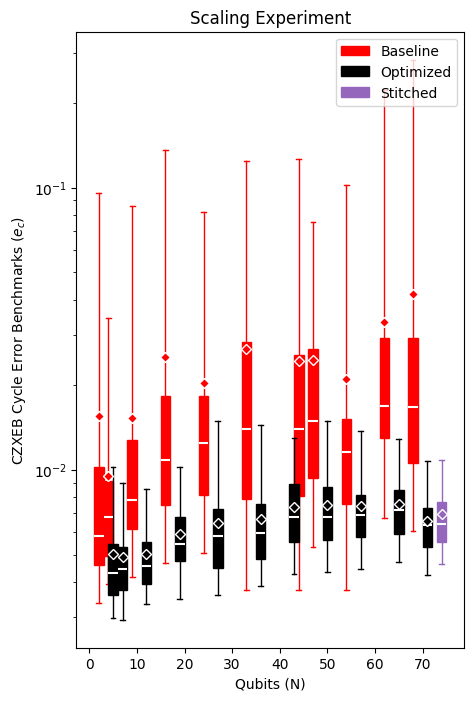

In [ ]:
# Define Plot
fig, axis = plt.subplots(1, figsize=(5, 8))
BOX_WIDTH = 2.0
DATA_OFFSET_FOR_CLARITY = 1.5 * BOX_WIDTH

# Plot Baselines
for num_qubits in figure_4a_baselines_df.N.unique():
    cz_data_for_num_qubits: list[float] = []
    for index, row in figure_4a_baselines_df.loc[figure_4a_baselines_df.N == num_qubits].iterrows():
        czxeb = parse_data_string(row["CZXEB"])
        cz_data_for_num_qubits.extend(list(czxeb.values()))
    baselines_boxplot = axis.boxplot(
        cz_data_for_num_qubits,
        positions=[int(num_qubits)],
        **build_box_plot_kwargs(color="r", widths=BOX_WIDTH),
    )

# Plot Optimized
for num_qubits in figure_4a_optimized_df.N.unique():
    cz_data_for_num_qubits: list[float] = []
    for index, row in figure_4a_optimized_df.loc[figure_4a_optimized_df.N == num_qubits].iterrows():
        czxeb = parse_data_string(row["CZXEB"])
        cz_data_for_num_qubits.extend(list(czxeb.values()))
    optimized_boxplot = axis.boxplot(
        cz_data_for_num_qubits,
        positions=[int(num_qubits) + DATA_OFFSET_FOR_CLARITY],
        **build_box_plot_kwargs(color="k", widths=BOX_WIDTH),
    )

# Plot Stitched
czxeb = parse_data_string(figure_4a_stitched_df.loc["Stitched", "CZXEB"])
stitched_boxplot = axis.boxplot(
    list(czxeb.values()),
    positions=[figure_4a_stitched_df.loc["Stitched", "N"] + 2 * DATA_OFFSET_FOR_CLARITY],
    **build_box_plot_kwargs(color="C4", widths=BOX_WIDTH),
)

# Format Axes
axis.set_xticks(np.arange(0, 80, 10))
axis.set_xticklabels(np.arange(0, 80, 10))
axis.set_yscale("log")

axis.set_title("Scaling Experiment")
axis.set_ylabel(r"CZXEB Cycle Error Benchmarks ($e_c$)")
axis.set_xlabel("Qubits (N)")

axis.legend(
    [baselines_boxplot["boxes"][0], optimized_boxplot["boxes"][0], stitched_boxplot["boxes"][0]],
    ["Baseline", "Optimized", "Stitched"],
    loc="upper right",
)

# Figure 4b

In [ ]:
figure_4b_df = pd.read_csv(DIRECTORY + "figure_4b_processed.csv", index_col=0)
figure_4b_df

,N,Distance,Scope,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Optimized,17,3,2.0,"((('q0_2', 'q0_3'), 0.0037744805951029615), ((...","(('q0_2', 0.00058233235823799), ('q0_3', 0.000...","(('q2_2', 6.26399999999953), ('q1_2', 5.957999...","((('q1_2', 'q2_2'), 6.0999999999995485), (('q2...",0
Optimized,49,5,2.0,"((('q0_4', 'q0_5'), 0.0038053382767019796), ((...","(('q0_4', 0.0005856877608172447), ('q0_5', 0.0...","(('q4_1', 6.311999999999525), ('q3_1', 6.00199...","((('q3_1', 'q4_1'), 6.151999999999543), (('q4_...",0
Optimized,97,7,2.0,"((('q0_6', 'q0_7'), 0.004150053718619665), (('...","(('q0_6', 0.0006004698666885436), ('q0_7', 0.0...","(('q2_9', 6.0719999999995515), ('q2_8', 5.7599...","((('q2_8', 'q2_9'), 5.915999999999569), (('q2_...",0
Optimized,161,9,2.0,"((('q0_8', 'q0_9'), 0.005017728521293202), (('...","(('q0_8', 0.0010366853985660255), ('q0_9', 0.0...","(('q12_12', 6.227999999999534), ('q11_12', 5.9...","((('q11_12', 'q12_12'), 6.0719999999995515), (...",0
Optimized,241,11,2.0,"((('q0_10', 'q0_11'), 0.0028977968757917857), ...","(('q0_10', 0.0004917559446846937), ('q0_11', 0...","(('q14_13', 6.203999999999537), ('q13_13', 5.8...","((('q13_13', 'q14_13'), 6.043999999999555), ((...",0
Optimized,337,13,2.0,"((('q0_12', 'q0_13'), 0.004190612790913727), (...","(('q0_12', 0.0007088923215601906), ('q0_13', 0...","(('q6_18', 6.211999999999536), ('q6_17', 5.857...","((('q6_17', 'q6_18'), 5.99399999999956), (('q6...",0
Optimized,449,15,2.0,"((('q0_14', 'q0_15'), 0.0032348968791791792), ...","(('q0_14', 0.000746863078323615), ('q0_15', 0....","(('q27_14', 6.403999999999515), ('q26_14', 6.0...","((('q26_14', 'q27_14'), 6.237999999999533), ((...",0
Optimized,577,17,2.0,"((('q0_16', 'q0_17'), 0.0029792166704945217), ...","(('q0_16', 0.0006274959732511854), ('q0_17', 0...","(('q24_16', 6.073999999999551), ('q23_16', 6.3...","((('q23_16', 'q24_16'), 6.187999999999539), ((...",0
Optimized,721,19,2.0,"((('q0_18', 'q0_19'), 0.004959098255871645), (...","(('q0_18', 0.0006093533556493152), ('q0_19', 0...","(('q18_36', 6.031999999999556), ('q18_35', 6.1...","((('q18_35', 'q18_36'), 5.9999999999995595), (...",0
Optimized,881,21,2.0,"((('q0_20', 'q0_21'), 0.003947562649888851), (...","(('q0_20', 0.0006152369037611173), ('q0_21', 0...","(('q32_13', 6.17799999999954), ('q31_13', 6.25...","((('q31_13', 'q32_13'), 6.1179999999995465), (...",0


In [ ]:
figure_4b_baselines_df = figure_4b_df.loc[figure_4b_df.index.str.contains("Baseline")]
figure_4b_baselines_df

,N,Distance,Scope,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Baseline,17,3,NaN,"((('q0_2', 'q0_3'), 0.005486181856988782), (('...","(('q0_2', 0.0011565347076037183), ('q0_3', 0.0...","(('q1_2', 5.667999999999596), ('q0_2', 5.69999...","((('q1_1', 'q1_2'), 5.759999999999586), (('q0_...",0
Baseline,49,5,NaN,"((('q0_4', 'q0_5'), 0.03410729708465556), (('q...","(('q0_4', 0.0010112908617466961), ('q0_5', 0.0...","(('q3_4', 5.849999999999576), ('q2_4', 6.20399...","((('q3_3', 'q3_4'), 5.5459999999996095), (('q1...",0
Baseline,97,7,NaN,"((('q0_6', 'q0_7'), 0.013233820071731864), (('...","(('q0_6', 0.0007862435403720395), ('q0_7', 0.0...","(('q9_10', 5.771999999999585), ('q8_10', 5.785...","((('q9_9', 'q9_10'), 5.657999999999597), (('q1...",0
Baseline,161,9,NaN,"((('q0_8', 'q0_9'), 0.007343128883485981), (('...","(('q0_8', 0.0012003369020514654), ('q0_9', 0.0...","(('q11_7', 5.787999999999583), ('q10_7', 5.861...","((('q11_6', 'q11_7'), 5.443999999999621), (('q...",0
Baseline,241,11,NaN,"((('q0_10', 'q0_11'), 0.01426596350784648), ((...","(('q0_10', 0.0005759073984019257), ('q0_11', 0...","(('q10_1', 5.825999999999579), ('q10_0', 5.861...","((('q10_1', 'q11_1'), 5.317999999999635), (('q...",0
Baseline,337,13,NaN,"((('q0_12', 'q0_13'), 0.010346959922461122), (...","(('q0_12', 0.0005036357585002694), ('q0_13', 0...","(('q14_20', 5.8179999999995795), ('q13_20', 5....","((('q14_20', 'q14_21'), 5.167999999999651), ((...",0
Baseline,449,15,NaN,"((('q0_14', 'q0_15'), 0.03477673931530804), ((...","(('q0_14', 0.0023533849637694007), ('q0_15', 0...","(('q1_12', 5.759999999999586), ('q1_13', 6.005...","((('q10_6', 'q10_7'), 5.641999999999599), (('q...",0
Baseline,577,17,NaN,"((('q0_16', 'q0_17'), 0.009720612268860937), (...","(('q0_16', 0.0006398412951434311), ('q0_17', 0...","(('q25_12', 5.821999999999579), ('q24_12', 5.8...","((('q21_21', 'q21_22'), 5.477999999999617), ((...",0
Baseline,721,19,NaN,"((('q0_18', 'q0_19'), 0.005014919057226559), (...","(('q0_18', 0.0013324130664890807), ('q0_19', 0...","(('q15_24', 5.751999999999587), ('q14_24', 6.0...","((('q14_12', 'q15_12'), 5.465999999999618), ((...",0
Baseline,881,21,NaN,"((('q0_20', 'q0_21'), 0.033138873737871104), (...","(('q0_20', 0.015742799376316972), ('q0_21', 0....","(('q26_20', 5.671999999999596), ('q25_20', 6.0...","((('q26_20', 'q27_20'), 5.115999999999657), ((...",0


In [ ]:
figure_4b_optimized_df = figure_4b_df.loc[figure_4b_df.index.str.contains("Optimized")]
figure_4b_optimized_df

,N,Distance,Scope,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Optimized,17,3,2.0,"((('q0_2', 'q0_3'), 0.0037744805951029615), ((...","(('q0_2', 0.00058233235823799), ('q0_3', 0.000...","(('q2_2', 6.26399999999953), ('q1_2', 5.957999...","((('q1_2', 'q2_2'), 6.0999999999995485), (('q2...",0
Optimized,49,5,2.0,"((('q0_4', 'q0_5'), 0.0038053382767019796), ((...","(('q0_4', 0.0005856877608172447), ('q0_5', 0.0...","(('q4_1', 6.311999999999525), ('q3_1', 6.00199...","((('q3_1', 'q4_1'), 6.151999999999543), (('q4_...",0
Optimized,97,7,2.0,"((('q0_6', 'q0_7'), 0.004150053718619665), (('...","(('q0_6', 0.0006004698666885436), ('q0_7', 0.0...","(('q2_9', 6.0719999999995515), ('q2_8', 5.7599...","((('q2_8', 'q2_9'), 5.915999999999569), (('q2_...",0
Optimized,161,9,2.0,"((('q0_8', 'q0_9'), 0.005017728521293202), (('...","(('q0_8', 0.0010366853985660255), ('q0_9', 0.0...","(('q12_12', 6.227999999999534), ('q11_12', 5.9...","((('q11_12', 'q12_12'), 6.0719999999995515), (...",0
Optimized,241,11,2.0,"((('q0_10', 'q0_11'), 0.0028977968757917857), ...","(('q0_10', 0.0004917559446846937), ('q0_11', 0...","(('q14_13', 6.203999999999537), ('q13_13', 5.8...","((('q13_13', 'q14_13'), 6.043999999999555), ((...",0
Optimized,337,13,2.0,"((('q0_12', 'q0_13'), 0.004190612790913727), (...","(('q0_12', 0.0007088923215601906), ('q0_13', 0...","(('q6_18', 6.211999999999536), ('q6_17', 5.857...","((('q6_17', 'q6_18'), 5.99399999999956), (('q6...",0
Optimized,449,15,2.0,"((('q0_14', 'q0_15'), 0.0032348968791791792), ...","(('q0_14', 0.000746863078323615), ('q0_15', 0....","(('q27_14', 6.403999999999515), ('q26_14', 6.0...","((('q26_14', 'q27_14'), 6.237999999999533), ((...",0
Optimized,577,17,2.0,"((('q0_16', 'q0_17'), 0.0029792166704945217), ...","(('q0_16', 0.0006274959732511854), ('q0_17', 0...","(('q24_16', 6.073999999999551), ('q23_16', 6.3...","((('q23_16', 'q24_16'), 6.187999999999539), ((...",0
Optimized,721,19,2.0,"((('q0_18', 'q0_19'), 0.004959098255871645), (...","(('q0_18', 0.0006093533556493152), ('q0_19', 0...","(('q18_36', 6.031999999999556), ('q18_35', 6.1...","((('q18_35', 'q18_36'), 5.9999999999995595), (...",0
Optimized,881,21,2.0,"((('q0_20', 'q0_21'), 0.003947562649888851), (...","(('q0_20', 0.0006152369037611173), ('q0_21', 0...","(('q32_13', 6.17799999999954), ('q31_13', 6.25...","((('q31_13', 'q32_13'), 6.1179999999995465), (...",0


In [ ]:
figure_4b_stitched_df = figure_4b_df.loc[figure_4b_df.index.str.contains("Stitched")]
figure_4b_stitched_df

,N,Distance,Scope,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Stitched,1057,23,2.0,"((('q23_5', 'q23_6'), 0.007743853843374), (('q...","(('q0_22', 0.0004283144372365651), ('q0_23', 0...","(('q36_23', 6.049999999999554), ('q35_23', 5.7...","((('q35_23', 'q36_23'), 5.873999999999573), ((...",0


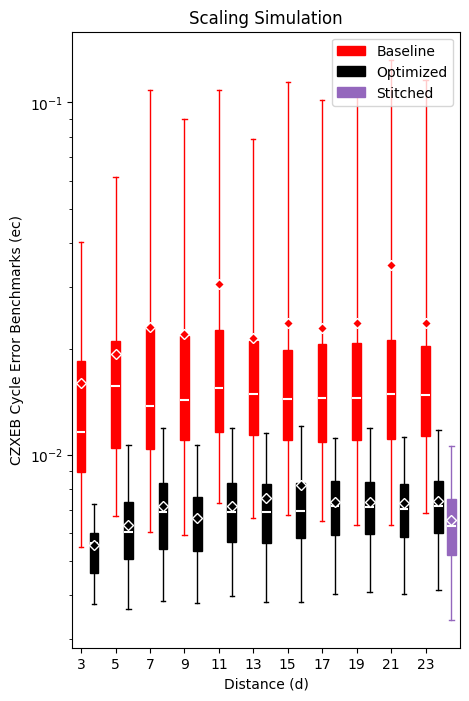

In [ ]:
# Define Plot
fig, axis = plt.subplots(1, figsize=(5, 8))
BOX_WIDTH = 0.5
DATA_OFFSET_FOR_CLARITY = 1.5 * BOX_WIDTH

# Plot Baselines
for index, row in figure_4b_baselines_df.iterrows():
    czxeb = parse_data_string(row["CZXEB"])
    baselines_boxplot = axis.boxplot(
        czxeb.values(),
        positions=[row.Distance],
        **build_box_plot_kwargs(color="r", widths=BOX_WIDTH),
    )

# Plot Optimized
for index, row in figure_4b_optimized_df.iterrows():
    czxeb = parse_data_string(row["CZXEB"])
    optimized_boxplot = axis.boxplot(
        czxeb.values(),
        positions=[row.Distance + DATA_OFFSET_FOR_CLARITY],
        **build_box_plot_kwargs(color="k", widths=BOX_WIDTH),
    )

# Plot Stitched
czxeb = parse_data_string(figure_4b_stitched_df.loc["Stitched", "CZXEB"])
stitched_boxplot = axis.boxplot(
    list(czxeb.values()),
    positions=[figure_4b_stitched_df.loc["Stitched", "Distance"] + 2 * DATA_OFFSET_FOR_CLARITY],
    **build_box_plot_kwargs(color="C4", widths=BOX_WIDTH),
)

# Format Axes
axis.set_xticks(np.arange(3, 24, 2))
axis.set_xticklabels(np.arange(3, 24, 2))
axis.set_yscale("log")
axis.set_title("Scaling Simulation")
axis.set_ylabel(r"CZXEB Cycle Error Benchmarks ($e_c$)")
axis.set_xlabel("Distance (d)")

axis.legend(
    [baselines_boxplot["boxes"][0], optimized_boxplot["boxes"][0], stitched_boxplot["boxes"][0]],
    ["Baseline", "Optimized", "Stitched"],
    loc="upper right",
)

# Figure 4c
NOTE: This cell loads the data necessary to produce this plot, but does not actually perform any plotting.

In [ ]:
figure_4c_df = pd.read_csv(DIRECTORY + "figure_4c_processed.csv", index_col=0)
figure_4c_df

,N,Scope,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Region 0,29,2,"((('q5_0', 'q5_1'), 0.006894288008864158), (('...","(('q1_4', 0.0007347176282181955), ('q2_3', 0.0...","(('q1_4', 5.963999999999563), ('q2_3', 5.80799...","((('q5_0', 'q5_1'), 5.641999999999599), (('q4_...",0
Region 1,28,2,"((('q5_6', 'q6_6'), 0.00980790538556317), (('q...","(('q2_6', 0.0014087120426677924), ('q2_7', 0.0...","(('q2_6', 5.830576640334739), ('q2_7', 6.12792...","((('q5_6', 'q6_6'), 6.037999999999555), (('q5_...",0
Merged Regions,68,2,"((('q9_4', 'q9_5'), 0.006414496217790111), (('...","(('q0_5', 0.0006160119353951221), ('q1_4', 0.0...","(('q0_5', 6.0899999999995496), ('q1_4', 5.9639...","((('q9_4', 'q9_5'), 5.928059000876754), (('q5_...",0
Healed Regions,68,2,"((('q9_4', 'q9_5'), 0.005095419658197015), (('...","(('q0_5', 0.0006422877290824247), ('q1_4', 0.0...","(('q0_5', 6.0899999999995496), ('q1_4', 5.9639...","((('q9_4', 'q9_5'), 5.928059000876754), (('q5_...",0


# Figure 4d
NOTE: This cell loads the data necessary to produce this plot, but does not actually perform any plotting.

In [ ]:
figure_4d_df = pd.read_csv(DIRECTORY + "figure_4d_processed.csv", index_col=0)
figure_4d_df

,N,Scope,CZXEB,SQRB,idle_freqs_GHz,int_freqs_GHz,Calibration Failures
Region 0,241,2,"((('q31_16', 'q32_16'), 0.0033115217255639414)...","(('q24_22', 0.0007006395304568305), ('q24_23',...","(('q36_23', 6.049999999999554), ('q35_23', 5.7...","((('q35_23', 'q36_23'), 5.873999999999573), ((...",0
Region 1,241,2,"((('q8_20', 'q8_21'), 0.0072629007702357876), ...","(('q0_22', 0.0004283144372365651), ('q0_23', 0...","(('q6_17', 6.231999999999534), ('q5_17', 5.925...","((('q5_17', 'q6_17'), 6.073999999999551), (('q...",0
Region 2,241,2,"((('q16_33', 'q17_33'), 0.005590559318366499),...","(('q12_34', 0.0005969063179489737), ('q12_35',...","(('q18_35', 6.1359999999995445), ('q17_35', 5....","((('q17_35', 'q18_35'), 5.979999999999562), ((...",0
Region 3,241,2,"((('q19_10', 'q19_11'), 0.007381020410131535),...","(('q12_10', 0.0007536742158404292), ('q12_11',...","(('q15_7', 6.157999999999542), ('q15_6', 5.847...","((('q15_6', 'q15_7'), 5.9999999999995595), (('...",0
Merged Regions,1057,2,"((('q23_5', 'q23_6'), 0.0075392443176813964), ...","(('q0_22', 0.0004283144372365651), ('q0_23', 0...","(('q36_23', 6.049999999999554), ('q35_23', 5.7...","((('q35_23', 'q36_23'), 5.873999999999573), ((...",0
Healed Regions,1057,2,"((('q23_5', 'q23_6'), 0.007743853843374), (('q...","(('q0_22', 0.0004283144372365651), ('q0_23', 0...","(('q36_23', 6.049999999999554), ('q35_23', 5.7...","((('q35_23', 'q36_23'), 5.873999999999573), ((...",0
